In [2]:
import time

import numpy as np

from scipy import special, integrate, spatial

import sympy
from sympy.printing.numpy import SciPyPrinter

from astropy import units as u

In [3]:
from matplotlib import pyplot as plt 

In [4]:
BN_ICOEFFS = [2, -1/3, 4/405, 46/25515, 131/1148175, -2194697/30690717750]

def f_bn(n):
    """
    Ciotti and Bertin 99, valid for n >~ 0.36
    """
    return np.sum([C*n**(1-i) for i, C in enumerate(BN_ICOEFFS)], axis=0)

def sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return Ie * np.exp(-bn*((R/Re)**(1/n)-1))

def log_sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return np.log(Ie) - bn*((R/Re)**(1/n)-1)

# Analytic inversion of the sersic function

In [5]:
Ie, R, Re, bn, n, x, U, γ = sympy.symbols('I_e, R, R_e, b_n, n, x, U, γ', real=True, positive=True)

sersic = Ie*sympy.exp(-bn*((R/Re)**(1/n)-1))
sersic

I_e*exp(-b_n*((R/R_e)**(1/n) - 1))

In [6]:
integ = sympy.integrate(sersic*R, (R, 0, x)).simplify()
integ

I_e*R_e**2*n*exp(b_n)*lowergamma(2*n, b_n*x**(1/n)/R_e**(1/n))/b_n**(2*n)

In [7]:
finteg = sympy.lambdify((x, Re, n, bn, Ie), integ)
SciPyPrinter().doprint(integ).replace('numpy.','np.').replace('scipy.special', 'special').replace('_','')

'Ie*Re**2*bn**(-2*n)*n*np.exp(bn)*special.gamma(2*n)*special.gammainc(2*n, Re**(-1/n)*bn*x**(n**(-1.0)))'

In [8]:
# raises NotImplementedError
#sympy.solve(integ - U, x)

We can live with that, since scipy has an inverse lower gamma, we can just solve for the lowergamma instead.

In [9]:
gammal = integ.args[-1]
assert isinstance(gammal, sympy.lowergamma)  # it should always be the last arg?

solns = sympy.solve(integ.subs({gammal: γ}) - U, γ)
assert len(solns) == 1
soln = solns[0]
sympy.Eq(γ, soln)

Eq(γ, U*b_n**(2*n)*exp(-b_n)/(I_e*R_e**2*n))

In [10]:
SciPyPrinter().doprint(soln).replace('numpy.','np.')

'U*b_n**(2*n)*np.exp(-b_n)/(I_e*R_e**2*n)'

In [11]:
gammal

lowergamma(2*n, b_n*x**(1/n)/R_e**(1/n))

Important: the scipy gamma is slighly different from the sympy gamma!:

In [12]:
SciPyPrinter().doprint(gammal).replace('scipy.special', 'special')

'special.gamma(2*n)*special.gammainc(2*n, R_e**(-1/n)*b_n*x**(n**(-1.0)))'

In [13]:
gammal.args[1]

b_n*x**(1/n)/R_e**(1/n)

In [14]:
def sersic_distribution(U, Re, n, Router=np.inf):
    bn = f_bn(n)

    Iemax = 1/finteg(Router, Re, n, bn, 1)

    sympy_gamma = U*bn**(2*n)*np.exp(-bn)/(Iemax*Re**2*n)
    gamma_arg = special.gammaincinv(2*n, sympy_gamma / special.gamma(2*n))
    return Re*(gamma_arg/bn)**n

sersic_distribution(.5, 1, 2)

np.float64(0.9999974417319889)

# Mock galaxy generators

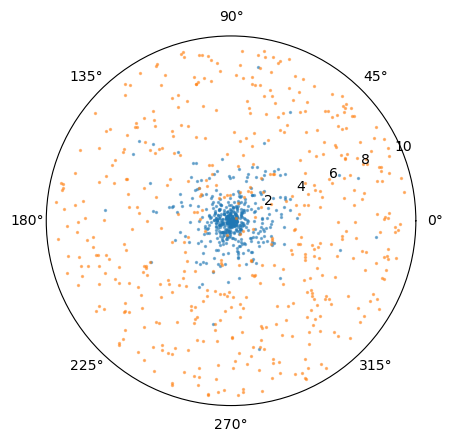

In [15]:
def sersic_plus_uniform_circle(ntotal, fbkg, n, Re=1, Router=10, polar_out=True):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    r_bkg = np.sqrt(np.random.rand(nbkg))*Router
    θ_bkg = np.random.rand(nbkg)*2*np.pi

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi

    r, θ = np.concatenate([r_fg, r_bkg]), np.concatenate([θ_fg, θ_bkg])

    if polar_out:
        return r, θ, nfg
    else:
        x = r*np.cos(θ)
        y = r*np.sin(θ)
        return x, y, nfg

r, θ, nfg = sersic_plus_uniform_circle(1000, .5, 2, Re=1)

plt.polar()
plt.scatter(θ[:nfg], r[:nfg], s=2, alpha=.5)
plt.scatter(θ[-nfg:], r[-nfg:], s=2, alpha=.5)
plt.grid(False);

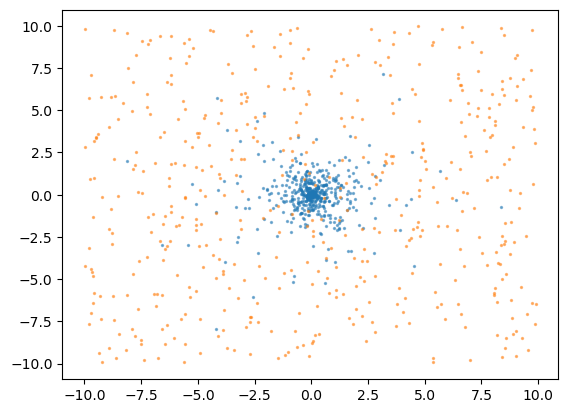

In [16]:
def sersic_plus_uniform_box(ntotal, fbkg, n, Re=1, Router=10):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    x_bkg = np.random.rand(nbkg)*Router*2 - Router
    y_bkg = np.random.rand(nbkg)*Router*2 - Router

    r_fg = sersic_distribution(np.random.rand(nfg), Re, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi
    
    x_fg = r_fg*np.cos(θ_fg)
    y_fg = r_fg*np.sin(θ_fg)

    return np.concatenate([x_fg, x_bkg]), np.concatenate([y_fg, y_bkg]), nfg

x, y, nfg = sersic_plus_uniform_box(1000, .5, 2, Re=1)

plt.scatter(x[:nfg], y[:nfg], s=2, alpha=.5)
plt.scatter(x[-nfg:], y[-nfg:], s=2, alpha=.5)

# Compute the true sersic integrals over a box or circular survey

In [17]:
def circle_sersic_integral(n, Re, Router):
    return integrate.quad(lambda r:r*sersic_profile(r, Ie=1, Re=Re, n=n)*2*np.pi, 0, Router)

circle_sersic_integral(2, 1, 1)[0]/circle_sersic_integral(2, 1, np.inf)[0], circle_sersic_integral(2, 1, np.inf)

(0.5000009854915142, (16.31087363948515, 5.56194486023287e-08))

In [18]:
def box_sersic_integral(n, Re, left, right, bottom, top):
    return integrate.dblquad(lambda y,x:sersic_profile(np.hypot(x, y), Ie=1, Re=Re, n=n), 
                             left, right, 
                             lambda x:bottom, lambda x:top)

box_sersic_integral(2, 1, -10, 10, -10, 10)

(16.277646704888625, 1.644423664730766e-07)

# Creating hulls from data points

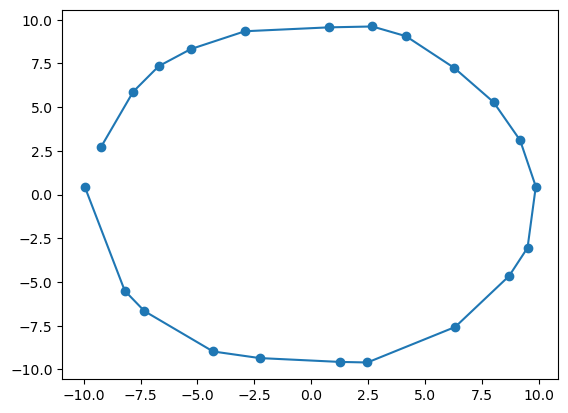

In [19]:
x, y, _ = sersic_plus_uniform_circle(1000, .5, 2, Re=1, polar_out=False)
hull_circ = spatial.ConvexHull(np.array((x, y)).T)
plt.plot(*hull_circ.points[hull_circ.vertices].T, 'o-')

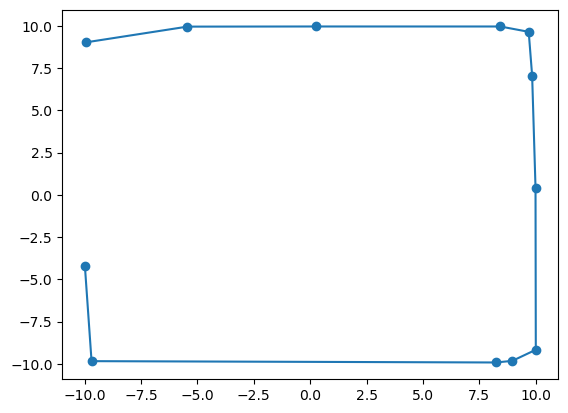

In [20]:
x, y, _ = sersic_plus_uniform_box(1000, .5, 2, Re=1)
hull_box = spatial.ConvexHull(np.array((x, y)).T)
plt.plot(*hull_box.points[hull_box.vertices].T, 'o-')

# Integrals from hulls

Using the greens theorem approach from [greenstheorem_sersic.ipynb](greenstheorem_sersic.ipynb). Re-derive here with the added scaling factors:

In [21]:
Ie, R, Re, bn, n = sympy.symbols('I_e, R, R_e, b_n, n', real=True, positive=True)
θ, x, y, Δx, Δy = sympy.symbols('θ, x, y, Δx, Δy', real=True)

In [22]:
Fr = R-R
Fθ = sympy.integrate(R*sympy.exp(-bn*((R/Re)**(1/n)-1)), R)/R

Fθ.simplify()

R_e**2*n*exp(b_n)*lowergamma(2*n, R**(1/n)*b_n/R_e**(1/n))/(R*b_n**(2*n))

In [23]:
curlp = Ie*(sympy.diff(R*Fθ, R)  - sympy.diff(Fr, θ))/R
curlp.simplify()

I_e*exp(-R**(1/n)*b_n/R_e**(1/n) + b_n)

In [24]:
assert curlp.simplify() == sersic.simplify()

In [25]:
Fx = (Fr*x/R - Fθ*y/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})
Fy = (Fr*y/R + Fθ*x/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})

In [26]:
cartsoln = (Fx* Δx + Fy* Δy).simplify()
cartsoln

R_e**2*n*(x*Δy - y*Δx)*exp(b_n)*lowergamma(2*n, b_n*(x**2 + y**2)**(1/(2*n))/R_e**(1/n))/(b_n**(2*n)*(x**2 + y**2))

In [27]:
SciPyPrinter().doprint(cartsoln).replace('scipy.special.', 'special.').replace('numpy.', 'np.')

'R_e**2*b_n**(-2*n)*n*(x*Δy - y*Δx)*np.exp(b_n)*special.gamma(2*n)*special.gammainc(2*n, R_e**(-1/n)*b_n*(x**2 + y**2)**((1/2)/n))/(x**2 + y**2)'

In [28]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

 First lets make sure we understand the scipy convex hull/qhull data format

In [29]:
vertxys = hull_circ.points[hull_circ.vertices].T
edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), 1000).T

int_segments = []
for x,y in edgexys:
    dx = x[1]-x[0]
    dy = y[1]-y[0]
    
    int_segments.append(dimensionless_path_integrand(x, y, dx, dy, Re=1, n=2))
np.array(int_segments), np.sum(int_segments)

(array([1.64213681, 0.38090931, 0.99565169, 0.54390078, 0.95304063,
        0.31545098, 1.15081327, 0.99329637, 0.47027256, 0.92329487,
        0.72470173, 0.66470045, 0.70712662, 0.73375904, 0.41042527,
        0.49479609, 0.99305058, 0.68421536, 0.44883201, 0.48169477,
        0.92855916, 0.62861452]),
 np.float64(16.2692428725999))

In [30]:
def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

sersic_integrate_hull(hull_circ, 1000, n=2, Re=1), sersic_integrate_hull(hull_box, 1000, n=2, Re=1)

(np.float64(16.2692428725999), np.float64(16.290692400032672))

Math works!  Huzzah! Now some accuracy/timing tests:

In [31]:
sersic_integrate_hull(hull_circ, 10000, n=2, Re=1)

np.float64(16.254906545835986)

In [32]:
sersic_integrate_hull(hull_circ, 100000, n=2, Re=1)

np.float64(16.253474303294247)

In [33]:
sersic_integrate_hull(hull_circ, 500000, n=2, Re=1)

np.float64(16.25334700515757)

General tests with easy analytic forms

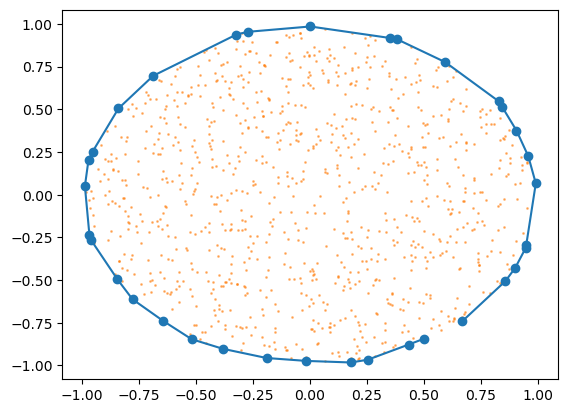

In [53]:
Redge1 = Redge = 1
n = 1000

r = np.sqrt(np.random.rand(n))*Redge
th = np.random.rand(len(r))*2*np.pi

x = r*np.cos(th)
y = r*np.sin(th)

hull_circ = spatial.ConvexHull(np.array((x, y)).T)
plt.scatter(x,y,s=1, alpha=.5, c='C1')
plt.plot(*hull_circ.points[hull_circ.vertices].T, 'o-')


In [54]:
sersic_integrate_hull(hull_circ, 10000, n=0.5, Re=Redge), integrate.quad(lambda r:2*np.pi*r*np.exp(-0.5*r**2), 0, Redge)

(np.float64(4.416931446436898), (2.4722407777192266, 2.744738633841089e-14))

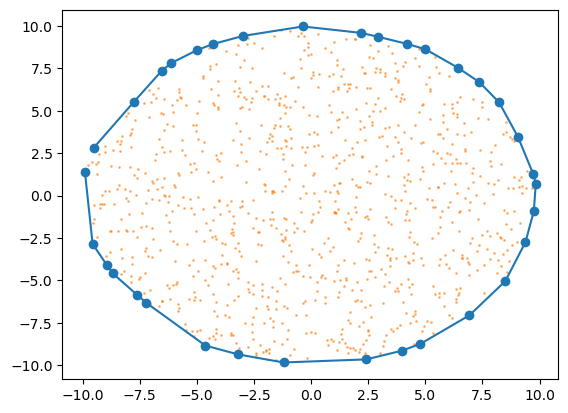

In [55]:
Redge2 = Redge = 10
n = 1000

r = np.sqrt(np.random.rand(n))*Redge
th = np.random.rand(len(r))*2*np.pi

x = r*np.cos(th)
y = r*np.sin(th)

hull_circ = spatial.ConvexHull(np.array((x, y)).T)
plt.scatter(x,y,s=1, alpha=.5, c='C1')
plt.plot(*hull_circ.points[hull_circ.vertices].T, 'o-')


In [56]:
sersic_integrate_hull(hull_circ, 10000, n=0.5, Re=Redge), integrate.quad(lambda r:2*np.pi*r*np.exp(-0.5*r**2), 0, Redge2)

(np.float64(441.25891133377814), (6.283185307179585, 5.250638379098763e-12))

Something's wrong - even if the bn factor is messing with things it should still limit to the same result at infinity :(  
    
# Try a few re-solve attempts

In [90]:
Ie, R, Re, bn, n = sympy.symbols('I_e, R, R_e, b_n, n', real=True, positive=True)
θ, x, y, Δx, Δy = sympy.symbols('θ, x, y, Δx, Δy', real=True)

In [91]:
Fr = R-R
Fθ = sympy.integrate(R*sympy.exp(-bn*((R/Re)**(1/n)-1)), R)/R

Fθ.simplify()

R_e**2*n*exp(b_n)*lowergamma(2*n, R**(1/n)*b_n/R_e**(1/n))/(R*b_n**(2*n))

In [92]:
curlp = Ie*(sympy.diff(R*Fθ, R)  - sympy.diff(Fr, θ))/R
curlp.simplify()

I_e*exp(-R**(1/n)*b_n/R_e**(1/n) + b_n)

In [93]:
assert curlp.simplify() == sersic.simplify()

In [ ]:
Fx = (Fr*x/R - Fθ*y/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})
Fy = (Fr*y/R + Fθ*x/R).subs({R:sympy.sqrt(x*x+y*y), θ:sympy.atan2(y,x)})

In [ ]:
cartsoln = (Fx* Δx + Fy* Δy).simplify()
cartsoln

R_e**2*n*(x*Δy - y*Δx)*exp(b_n)*lowergamma(2*n, b_n*(x**2 + y**2)**(1/(2*n))/R_e**(1/n))/(b_n**(2*n)*(x**2 + y**2))

In [ ]:
SciPyPrinter().doprint(cartsoln).replace('scipy.special.', 'special.').replace('numpy.', 'np.')

'R_e**2*b_n**(-2*n)*n*(x*Δy - y*Δx)*np.exp(b_n)*special.gamma(2*n)*special.gammainc(2*n, R_e**(-1/n)*b_n*(x**2 + y**2)**((1/2)/n))/(x**2 + y**2)'

In [246]:
sersic_gauss = sersic.subs({n:sympy.Rational(1,2)})
sersic_gauss

I_e*exp(-b_n*(R**2/R_e**2 - 1))

In [249]:
sersictopint = sympy.integrate(R*sersic_gauss, (R,0,sympy.oo)).simplify()
sersictopint

I_e*R_e**2*exp(b_n)/(2*b_n)

In [ ]:
X = sympy.symbols('X', real=True, positive=True)

In [250]:
sersicint = sympy.integrate(R*sersic_gauss, (R,0,X)).simplify()
sersicint

I_e*R_e**2*(exp(b_n) - exp(b_n*(R_e**2 - X**2)/R_e**2))/(2*b_n)

In [251]:
bn_gauss_soln = sympy.solve(sersicint.subs({X:Re}) - sersictopint/2, bn)
assert len(bn_gauss_soln) == 1
bn_gauss = bn_gauss_soln[0]
bn_gauss

log(2)

In [252]:
sersic_gauss.subs({bn:bn_gauss}).simplify()

2**(-R**2/R_e**2 + 1)*I_e

In [258]:
sersicint.subs({bn:bn_gauss, X:Re})

I_e*R_e**2/(2*log(2))

In [260]:
sersictopint.subs({bn:bn_gauss})

I_e*R_e**2/log(2)

In [274]:
fsersicint = sympy.lambdify((X, Ie, Re), sersicint.subs({bn:bn_gauss}))

In [263]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

sersic_integrate_hull(hull_circ, 10000, n=0.5, Re=1), 2*np.pi/np.log(2)

(np.float64(9.06460414467746), np.float64(9.064720283654388))

In [271]:
def testReinf(Re, npoints=1000):
    return sersic_integrate_hull(hull_circ, npoints, n=0.5, Re=Re), 2*np.pi*Re**2/np.log(2)

testReinf(1),testReinf(2), testReinf(np.pi), testReinf(10), testReinf(0.05)

((np.float64(9.072684182281362), np.float64(9.064720283654388)),
 (np.float64(36.29073449528251), np.float64(36.25888113461755)),
 (np.float64(89.43877797886101), np.float64(89.46520320619932)),
 (np.float64(441.65517334821266), np.float64(906.4720283654387)),
 (np.float64(0.02268171045570341), np.float64(0.02266180070913597)))

The hull goes out to 10, so it should start failing for Re much larger than that... so that checks out! What about for the correctly scaled integral?

In [303]:
def testRe(Re, npoints=1000, Router=10, nhull=1000):
    r = np.sqrt(np.random.rand(nhull))*Router
    th = np.random.rand(len(r))*2*np.pi

    x = r*np.cos(th)
    y = r*np.sin(th)

    thishull = spatial.ConvexHull(np.array((x, y)).T)

    return sersic_integrate_hull(thishull, npoints, n=0.5, Re=Re), 2*np.pi*fsersicint(Router, 1, Re)

testRe(1), testRe(2), testRe(np.pi), testRe(10), testRe(0.05), testRe(100), testRe(100, npoints=100000, Router=25, nhull=20000), testRe(100, npoints=100000, Router=25, nhull=100),

((np.float64(9.072654355857981), np.float64(9.064720283654387)),
 (np.float64(36.29059022712379), np.float64(36.25888005401869)),
 (np.float64(89.44317662970283), np.float64(89.38548039481924)),
 (np.float64(441.29983756787897), np.float64(453.23601418271943)),
 (np.float64(0.022681740174307158), np.float64(0.02266180070913597)),
 (np.float64(609.1952777711695), np.float64(626.1459672133667)),
 (np.float64(3826.290517950233), np.float64(3843.1440141204143)),
 (np.float64(3170.248282232583), np.float64(3843.1440141204143)))

So there's some amount of intrinsic bias for the large size ones, but everythings pretty good inside the hull.

Next exeriment: try for general n

In [308]:
sersictopint = sympy.integrate(R*sersic, (R,0,sympy.oo)).simplify()
sersictopint

I_e*R_e**2*exp(b_n)*gamma(2*n + 1)/(2*b_n**(2*n))

In [309]:
sersicint = sympy.integrate(R*sersic, (R,0,X)).simplify()
sersicint

I_e*R_e**2*n*exp(b_n)*lowergamma(2*n, X**(1/n)*b_n/R_e**(1/n))/b_n**(2*n)

In [314]:
fsersicint = sympy.lambdify((X, Ie, Re, n, bn), sersicint)

def testRe(Re, npoints=1000, Router=10, nhull=1000, n=0.5):
    r = np.sqrt(np.random.rand(nhull))*Router
    th = np.random.rand(len(r))*2*np.pi

    x = r*np.cos(th)
    y = r*np.sin(th)

    thishull = spatial.ConvexHull(np.array((x, y)).T)
    bn = f_bn(n)

    return sersic_integrate_hull(thishull, npoints, n=n, Re=Re), 2*np.pi*fsersicint(Router, 1, Re, n, bn)

In [317]:
ntest = 0.5
testRe(1, n=ntest), testRe(2, n=ntest), testRe(np.pi, n=ntest), testRe(10, n=ntest), testRe(0.05, n=ntest), testRe(100, n=ntest)

((np.float64(9.072703780265908), np.float64(9.063707251123313)),
 (np.float64(36.290724764999084), np.float64(36.25482793081708)),
 (np.float64(89.45038981261818), np.float64(89.37569483688304)),
 (np.float64(442.2652025081232), np.float64(453.29982618986116)),
 (np.float64(0.02268163363245229), np.float64(0.022659268127808285)),
 (np.float64(609.5999454108263), np.float64(626.3033663249873)))

In [318]:
ntest = 1
testRe(1, n=ntest), testRe(2, n=ntest), testRe(np.pi, n=ntest), testRe(10, n=ntest), testRe(0.05, n=ntest), testRe(100, n=ntest)

((np.float64(11.960202019979889), np.float64(11.948388421077063)),
 (np.float64(47.72409879234452), np.float64(47.6918435870145)),
 (np.float64(114.14923914363244), np.float64(114.34781197821906)),
 (np.float64(586.0808508606993), np.float64(597.4355647386876)),
 (np.float64(0.0299005979950971), np.float64(0.029870998350458484)),
 (np.float64(1457.2398046036399), np.float64(1505.9578507426863)))

In [319]:
ntest = 2
testRe(1, n=ntest), testRe(2, n=ntest), testRe(np.pi, n=ntest), testRe(10, n=ntest), testRe(0.05, n=ntest), testRe(100, n=ntest)

((np.float64(16.27316872155934), np.float64(16.260505057449127)),
 (np.float64(62.8210474734046), np.float64(62.847525010497904)),
 (np.float64(143.13626025812553), np.float64(143.5379033917782)),
 (np.float64(804.6239721826632), np.float64(815.5452893970136)),
 (np.float64(0.04081762317208083), np.float64(0.04077718409940483)),
 (np.float64(4860.123633262225), np.float64(4975.1137295622475)))

In [320]:
ntest = 4
testRe(1, n=ntest), testRe(2, n=ntest), testRe(np.pi, n=ntest), testRe(10, n=ntest), testRe(0.05, n=ntest), testRe(100, n=ntest)

((np.float64(21.785859377905847), np.float64(21.792302487508692)),
 (np.float64(80.01864855152972), np.float64(80.19457265883368)),
 (np.float64(178.50490176053515), np.float64(179.17026147580327)),
 (np.float64(1124.0835519412944), np.float64(1133.2618373541475)),
 (np.float64(0.05671909009832243), np.float64(0.056663010457127835)),
 (np.float64(15967.668813365819), np.float64(16311.589280243816)))

In [323]:
dct = dict(n=4, npoints=100000, Router=10, nhull=20000)
testRe(1, **dct), testRe(2, **dct), testRe(np.pi, **dct), testRe(10, **dct), testRe(0.05, **dct), testRe(100, **dct)

((np.float64(21.78912165700714), np.float64(21.792302487508692)),
 (np.float64(80.16540784137251), np.float64(80.19457265883368)),
 (np.float64(179.06247260128112), np.float64(179.17026147580327)),
 (np.float64(1131.8896295819475), np.float64(1133.2618373541475)),
 (np.float64(0.056663574960811945), np.float64(0.056663010457127835)),
 (np.float64(16274.953678486881), np.float64(16311.589280243816)))

In [439]:
dct = dict(n=4, npoints=2000, Router=10, nhull=20000)
[np.diff(testRe(np.pi, **dct))[0] for _ in range(10)]

[np.float64(0.042957851392458224),
 np.float64(0.022053904228187093),
 np.float64(0.016551965400708468),
 np.float64(0.029436874020007053),
 np.float64(0.018153793070780466),
 np.float64(0.005319128243598925),
 np.float64(0.006935259555007178),
 np.float64(0.033591079592753204),
 np.float64(0.011127122760854036),
 np.float64(0.008498494376198096)]

In [451]:
dct = dict(n=4, npoints=15000, Router=10, nhull=25000)
[(lambda x:np.diff(x)[0]/x[1])(testRe(np.pi, **dct)) for _ in range(10)]

[np.float64(0.0003805338537997552),
 np.float64(0.00037989583011505265),
 np.float64(0.0003876048739489579),
 np.float64(0.0004300870653264473),
 np.float64(0.0004856806591444833),
 np.float64(0.00042702896417509705),
 np.float64(0.0005160946273556789),
 np.float64(0.0005775531716574395),
 np.float64(0.0004665368801752617),
 np.float64(0.0004515993555041659)]

For some reason the bias doesn't go away for various nhull and npoints?